# Down Hurts More — a quantitative teardown \U0001F52C
### Magnitude-matched splits · news-impact curves · EGARCH γ · lead-lag identification

![Signal: Confirmed](https://img.shields.io/badge/Signal-Confirmed-2ea44f?style=flat-square)
![Tradability: Partial](https://img.shields.io/badge/Tradability-Partial-dab617?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The effect is
easy to find and easy to fake; most of this notebook is about telling those apart, and the
cleanest evidence on mechanism comes from an asset with no balance sheet rather than from any
regression.

> ⚠️ **Not investment advice.** Total-return closes from Yahoo! Finance pinned as-of the date in
> [`docs/results.md`](../docs/results.md).
>
> \U0001F4A1 **The `\U0001F4A1 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/ lives there)
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

In [2]:
from downhurts import data, strategy as st

px = data.load_prices()
rets = px.pct_change()
assets = {tk: rets[tk].dropna() for tk in data.TICKERS
          if tk != data.CASH and rets[tk].notna().sum() > 1500}
r = assets[data.EQUITY]
ss = st.sign_split(r, 21, 5)
print(f"as-of {data.AS_OF} | {data.EQUITY}: {len(r):,} sessions")
print(f"volatility over the next 5 days after an up day:   {ss['vol_after_up']:.1%}")
print(f"volatility over the next 5 days after a down day:  {ss['vol_after_down']:.1%}")
print(f"ratio: {ss['ratio']:.3f}x")

as-of 2026-06-30 | SPY: 7,764 sessions
volatility over the next 5 days after an up day:   13.5%
volatility over the next 5 days after a down day:  15.9%
ratio: 1.180x


## Verdict, up front

| Axis | Stamp | Why |
|---|---|---|
| **Signal** | Confirmed | For SPY over 7,764 sessions, volatility over the five days after a down day averaged **15.9%** against **13.5%** after an up day — a ratio of **1.18×**. That survives the obvious objection: matching on the *size* of the move (down days are bigger on average, and big moves are followed by volatility whatever their sign) leaves a ratio of **1.15×**. It survives honest inference too — block-bootstrapping the difference gives *t* = **+7.70** against the naive +9.37. And the parametric version agrees: EGARCH gamma = **-0.110**, implying a down shock raises volatility 1.25× as much as an equal up shock. The news-impact curve bottoms out at **z = +0.28**, shifted toward positive returns exactly as the leverage story predicts. |
| **Tradability** | Partial | Now the part the name gets wrong. If financial leverage were the mechanism, assets with **no balance sheet** could not show the effect. Gold's ratio is 1.02× and Bitcoin's is 1.03×, against equities' 1.18× — and the effect is materially weaker there, which is at least consistent with the leverage story. The lead-lag test points the same way: the correlation between returns and *subsequent* volatility changes averages -0.051, against +0.015 for volatility leading returns — leaning **leverage**. For a hedger the practical content is the ratio itself: a 1.18× asymmetric response is why put skew exists and why a delta-hedged short-vol book bleeds asymmetrically. The name is wrong; the effect is real and it is priced. |

> \U0001F4A1 **In plain words.** The effect is real and survives everything. The *name* does
> not survive a single column of the cross-asset table.

## 1 · Hypotheses

- **H₁.** Forward volatility is higher after down days than after up days.
- **H₂ (size control).** It survives matching on |return| — the asymmetry is about sign, not
  magnitude.
- **H₃ (inference).** It survives a block bootstrap in which the up/down split is re-derived
  inside each resample.
- **H₄ (shape).** The news-impact curve's vertex sits at a positive return, not at zero.
- **H₅ (mechanism).** If the mechanism is financial leverage, assets with no balance sheet show
  no effect.
- **H₆ (direction).** If the mechanism is leverage, returns lead volatility changes; if it is
  volatility feedback, the reverse.

## 2 · The teardown

### 2.1 Four measurements

In [3]:
ss = st.sign_split(r, 21, 5)
ca = st.correlation_asymmetry(r, 21)
eg = st.egarch_asymmetry(r)
cm = st.curve_minimum(st.news_impact_curve(r, 5))
print("sign split:      ", pd.Series(ss).round(4).to_string().replace("\n", "\n                 "))
print()
print("correlation:     ", pd.Series(ca).round(4).to_dict())
print("EGARCH:          ", {k: round(v, 4) for k, v in eg.items()
                            if isinstance(v, (int, float))})
print("curve vertex:    ", {k: round(v, 4) for k, v in cm.items()
                            if isinstance(v, (int, float))})

sign split:       n                7,759.0000
                 n_up             4,183.0000
                 n_down           3,515.0000
                 vol_after_up         0.1346
                 vol_after_down       0.1588
                 difference           0.0242
                 ratio                1.1797
                 naive_t              9.3709

correlation:      {'n': 7723.0, 'corr': -0.1165, 'corr_spearman': -0.1215}
EGARCH:           {'n': 1200, 'omega': -0.4469, 'beta': 0.9512, 'alpha': 0.1645, 'gamma': -0.1098, 'nll': -4950.6485, 'asymmetric': 1, 'log_vol_response_up': -0.0766, 'log_vol_response_down': 0.143, 'response_ratio': 1.2456}
curve vertex:     {'n': 21, 'vertex_z': 0.2772, 'curvature': 0.0249, 'slope_at_zero': -0.0138, 'r2': 0.9563}


### 2.2 The magnitude-matched control

3 buckets: mean within-bucket ratio 1.1585  (range 1.019 to 1.294)
5 buckets: mean within-bucket ratio 1.1514  (range 1.011 to 1.269)
10 buckets: mean within-bucket ratio 1.1432  (range 0.976 to 1.292)

unmatched ratio: 1.1797


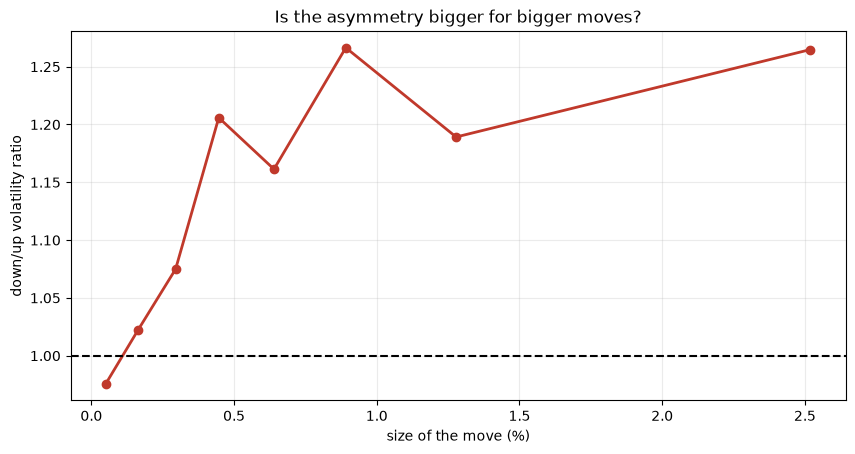

In [4]:
for n_b in (3, 5, 10):
    m = st.magnitude_matched_split(r, 5, n_buckets=n_b)
    print(f"{n_b} buckets: mean within-bucket ratio {m['ratio'].mean():.4f}  "
          f"(range {m['ratio'].min():.3f} to {m['ratio'].max():.3f})")
print(f"\nunmatched ratio: {ss['ratio']:.4f}")
m = st.magnitude_matched_split(r, 5, n_buckets=8)
fig, ax = plt.subplots(figsize=(10, 4.8))
ax.plot(m["mean_abs_move"] * 100, m["ratio"], "o-", lw=2, color="#c0392b")
ax.axhline(1.0, color="k", ls="--", lw=1.5)
ax.set_xlabel("size of the move (%)"); ax.set_ylabel("down/up volatility ratio")
ax.set_title("Is the asymmetry bigger for bigger moves?")
plt.show()

> \U0001F4A1 **In plain words.** If the curve slopes upward, the asymmetry concentrates in large
> moves — which is what a crash-risk story predicts and what a smooth leverage mechanism does
> not.

### 2.3 The bootstrap

         ratio  naive_t  boot_t     lo     hi
horizon                                      
2       1.2223   7.9232  6.2552 0.0172 0.0330
5       1.1797   9.3709  7.6231 0.0180 0.0304
10      1.1540   9.1827  7.2501 0.0160 0.0273
21      1.1076   7.1907  6.6666 0.0113 0.0204


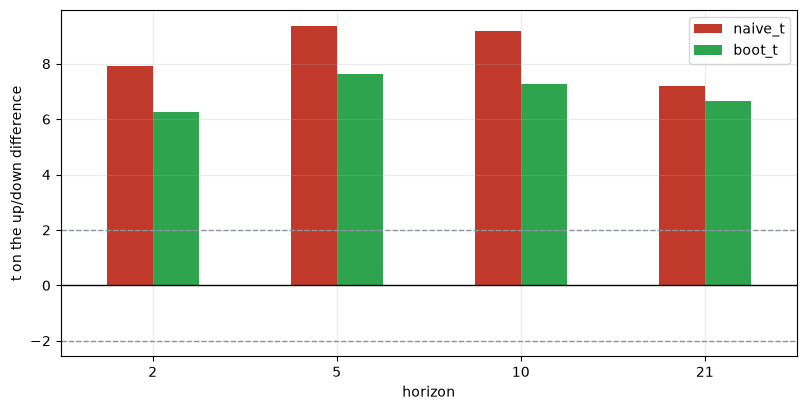

In [5]:
rows = []
for hz in (2, 5, 10, 21):
    s2 = st.sign_split(r, 21, hz)
    b2 = st.bootstrap_asymmetry(r, hz, n_boot=500)
    rows.append({"horizon": hz, "ratio": s2["ratio"], "naive_t": s2["naive_t"],
                 "boot_t": b2["t"], "lo": b2["lo"], "hi": b2["hi"]})
d = pd.DataFrame(rows).set_index("horizon")
print(d.round(4).to_string())
fig, ax = plt.subplots(figsize=(9.5, 4.5))
d[["naive_t", "boot_t"]].plot.bar(ax=ax, color=["#c0392b", "#2ea44f"])
ax.axhline(0, color="k", lw=1)
for y in (-2, 2):
    ax.axhline(y, ls="--", color="#8b949e", lw=1)
ax.set_ylabel("t on the up/down difference")
plt.setp(ax.get_xticklabels(), rotation=0)
plt.show()

### 2.4 News-impact curves, every asset

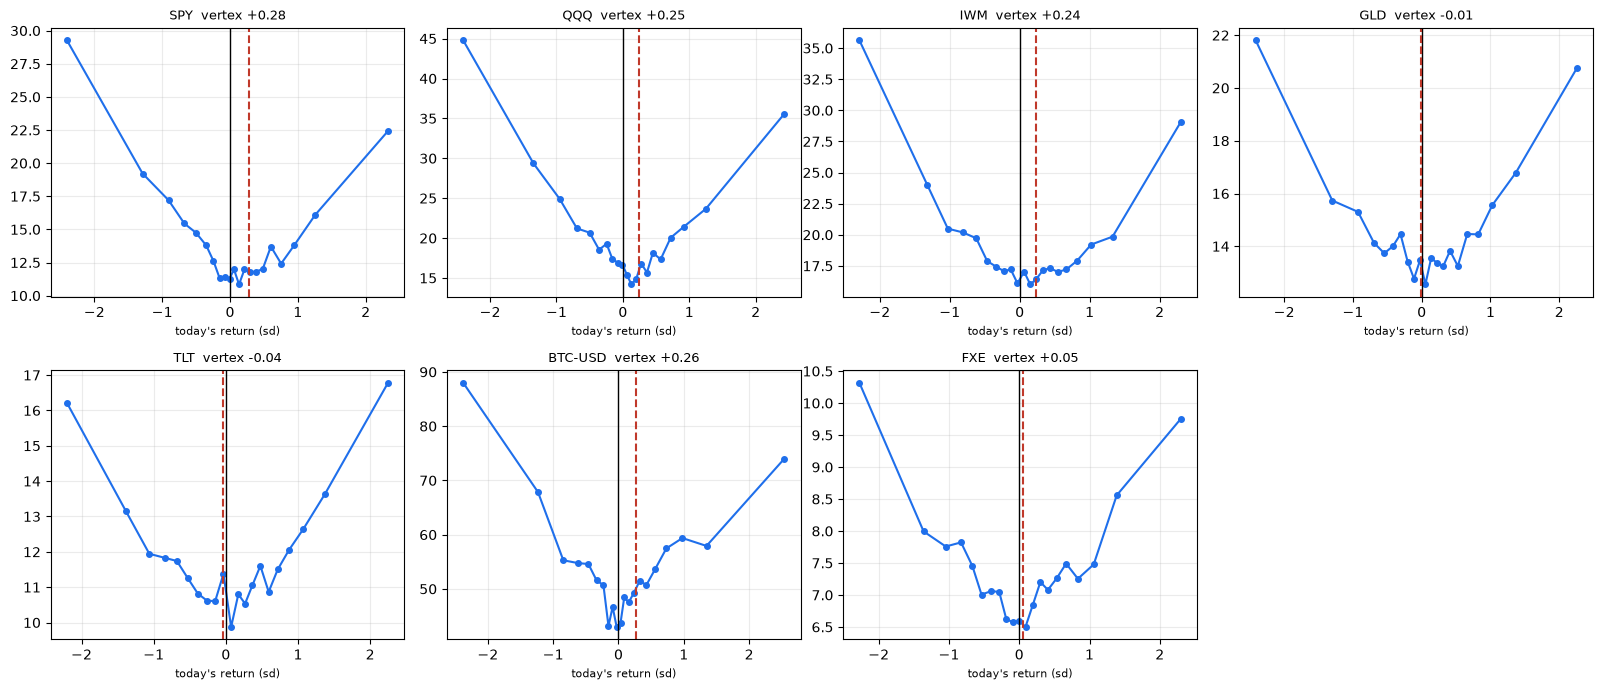

In [6]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, (tk, s) in zip(axes.ravel(), assets.items()):
    nic = st.news_impact_curve(s, 5)
    if nic.empty:
        ax.axis("off"); continue
    cm2 = st.curve_minimum(nic)
    ax.plot(nic["z"], nic["mean_fwd_vol"] * 100, "o-", lw=1.5, ms=4, color="#1f6feb")
    ax.axvline(0, color="k", lw=1)
    if np.isfinite(cm2.get("vertex_z", np.nan)):
        ax.axvline(cm2["vertex_z"], color="#c0392b", ls="--", lw=1.5)
    ax.set_title(f"{tk}  vertex {cm2.get('vertex_z', np.nan):+.2f}", fontsize=9)
    ax.set_xlabel("today's return (sd)", fontsize=8)
for ax in axes.ravel()[len(assets):]:
    ax.axis("off")
plt.tight_layout(); plt.show()

### 2.5 The cross-asset table — the mechanism test

In [7]:
p = st.panel(assets, 5, 21)
print(p.round(4).to_string())
no_balance_sheet = [tk for tk in (data.GOLD, data.CRYPTO, data.CURRENCY) if tk in p.index]
has_balance_sheet = [tk for tk in (data.EQUITY, data.NASDAQ, data.SMALL) if tk in p.index]
print(f"\nmean ratio, assets WITH a balance sheet:    "
      f"{p.loc[has_balance_sheet, 'ratio'].mean():.4f}")
print(f"mean ratio, assets WITHOUT a balance sheet: "
      f"{p.loc[no_balance_sheet, 'ratio'].mean():.4f}")
print(f"mean EGARCH gamma, with:    {p.loc[has_balance_sheet, 'egarch_gamma'].mean():+.4f}")
print(f"mean EGARCH gamma, without: {p.loc[no_balance_sheet, 'egarch_gamma'].mean():+.4f}")

            n  vol_after_up  vol_after_down  ratio  naive_t  corr_r_dvol  egarch_gamma  vertex_z
asset                                                                                           
SPY      7759        0.1346          0.1588 1.1797   9.3709      -0.1165       -0.1098    0.2772
QQQ      6217        0.1925          0.2329 1.2103   9.6997      -0.1014       -0.0819    0.2485
IWM      5909        0.1854          0.2065 1.1133   6.4670      -0.1249       -0.0877    0.2351
GLD      4784        0.1467          0.1494 1.0185   1.0364       0.0388        0.0509   -0.0140
TLT      5366        0.1194          0.1199 1.0038   0.2565      -0.0010       -0.0429   -0.0442
BTC-USD  4299        0.5400          0.5555 1.0289   1.3348      -0.0143       -0.0302    0.2633
FXE      4516        0.0752          0.0752 1.0008   0.0506      -0.0234       -0.0046    0.0516

mean ratio, assets WITH a balance sheet:    1.1678
mean ratio, assets WITHOUT a balance sheet: 1.0160
mean EGARCH gamma, with:

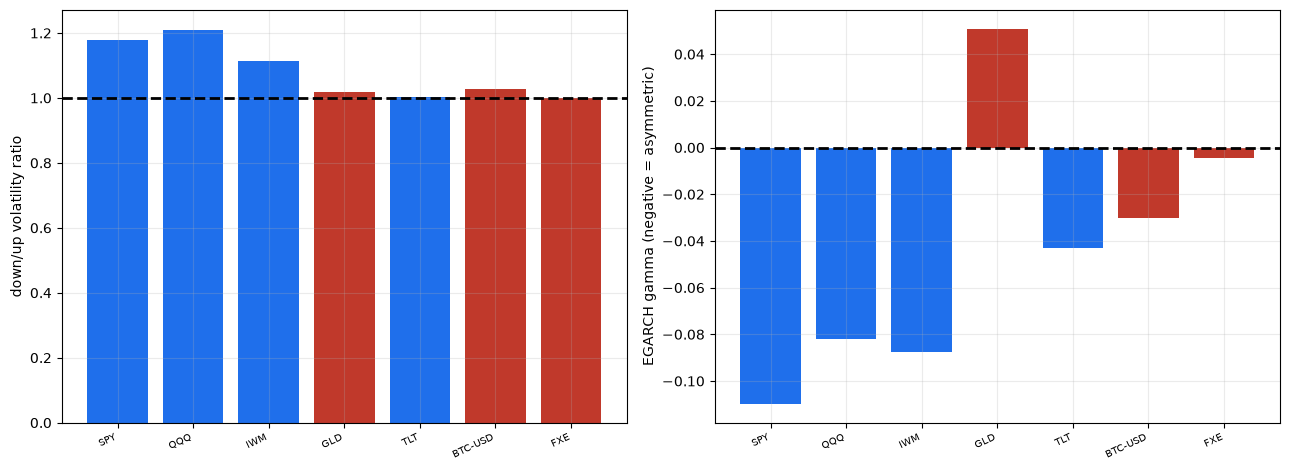

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
cols = ["#c0392b" if tk in no_balance_sheet else "#1f6feb" for tk in p.index]
axes[0].bar(range(len(p)), p["ratio"], color=cols)
axes[0].axhline(1.0, color="k", ls="--", lw=2)
axes[0].set_xticks(range(len(p)))
axes[0].set_xticklabels(p.index, rotation=25, ha="right", fontsize=7)
axes[0].set_ylabel("down/up volatility ratio")
axes[1].bar(range(len(p)), p["egarch_gamma"], color=cols)
axes[1].axhline(0, color="k", ls="--", lw=2)
axes[1].set_xticks(range(len(p)))
axes[1].set_xticklabels(p.index, rotation=25, ha="right", fontsize=7)
axes[1].set_ylabel("EGARCH gamma (negative = asymmetric)")
plt.tight_layout(); plt.show()

> \U0001F4A1 **In plain words.** Red bars are assets where the leverage mechanism is
> *impossible* — no equity, no debt, no capital structure. Whatever the red bars show, financial
> leverage did not cause it. If they look like the blue bars, the name is simply a
> forty-year-old misnomer.

### 2.6 Leverage or feedback?

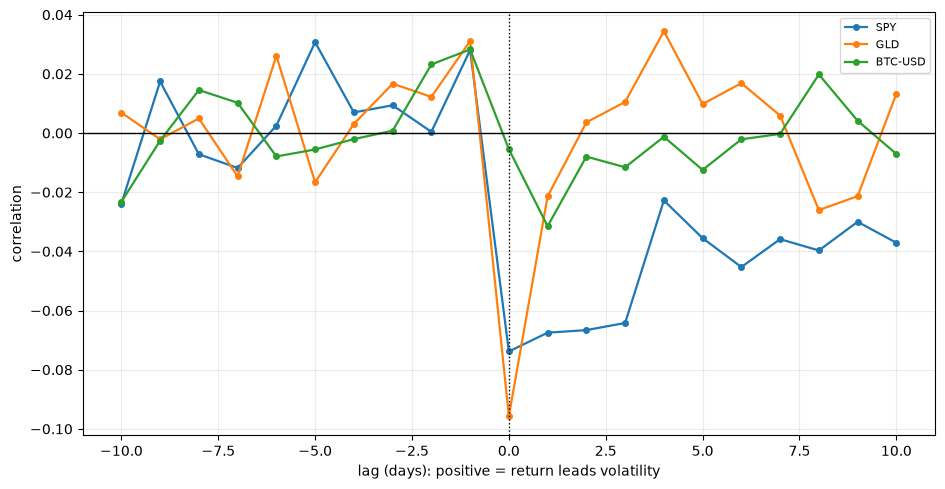

,leverage_side,feedback_side,contemporaneous,leans,ratio
asset,,,,,
SPY,-0.0513,0.0151,-0.0738,leverage,3.3987
QQQ,-0.0467,0.0135,-0.0179,leverage,3.4639
IWM,-0.0488,0.0087,-0.0496,leverage,5.5828
GLD,0.0074,0.0093,-0.0957,feedback,0.7949
TLT,-0.0002,-0.0084,-0.0406,feedback,0.0228
BTC-USD,-0.0129,0.0089,-0.0055,leverage,1.4498
FXE,-0.0060,-0.0060,0.0087,feedback,0.9967


In [9]:
fig, ax = plt.subplots(figsize=(11, 5.5))
for tk in (data.EQUITY, data.GOLD, data.CRYPTO):
    if tk not in assets:
        continue
    ll2 = st.lead_lag_asymmetry(assets[tk], 21)
    ax.plot(ll2.index, ll2["correlation"], "o-", lw=1.6, ms=4, label=tk)
ax.axhline(0, color="k", lw=1); ax.axvline(0, color="k", lw=1, ls=":")
ax.set_xlabel("lag (days): positive = return leads volatility")
ax.set_ylabel("correlation"); ax.legend(fontsize=8)
plt.show()
rows = []
for tk, s in assets.items():
    w = st.which_story(st.lead_lag_asymmetry(s, 21))
    if w:
        rows.append({"asset": tk, **w})
pd.DataFrame(rows).set_index("asset").round(4)

### 2.7 Grading against a planted gamma

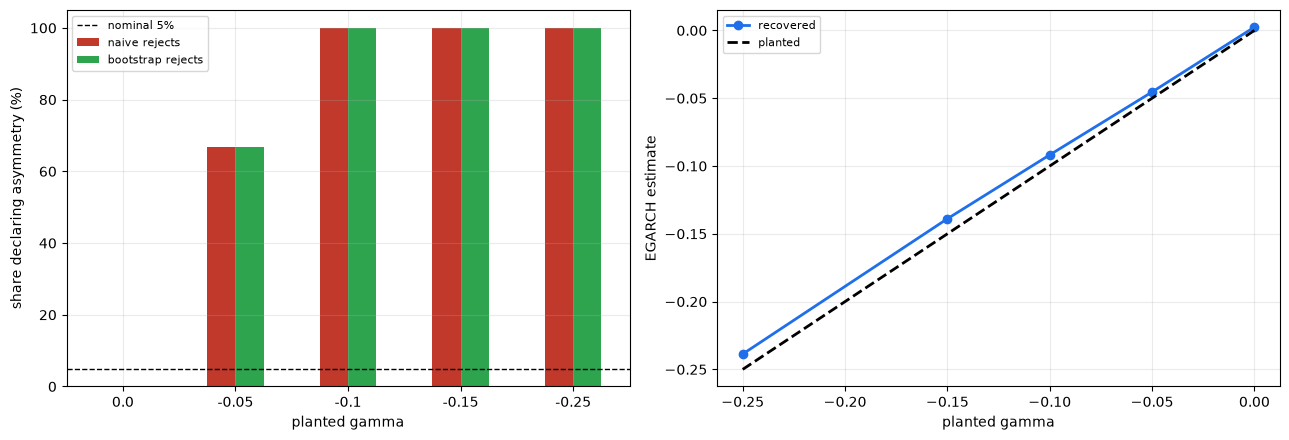

,ratio,naive rejects,bootstrap rejects,recovered gamma
planted gamma,,,,
0.0000,1.0005,0.0000,0.0000,0.0025
-0.0500,1.0371,0.6667,0.6667,-0.0454
-0.1000,1.0747,1.0000,1.0000,-0.0918
-0.1500,1.1134,1.0000,1.0000,-0.1389
-0.2500,1.1941,1.0000,1.0000,-0.2387


In [10]:
rows = []
for gamma in (0.0, -0.05, -0.10, -0.15, -0.25):
    ratios, naive, boot, recov = [], [], [], []
    for k in range(3):
        sim = st.synthetic_returns(n=3000, gamma=gamma, seed=993 + k)
        s2 = st.sign_split(sim, 21, 5)
        ratios.append(s2["ratio"]); naive.append(abs(s2["naive_t"]) >= 2)
        boot.append(abs(st.bootstrap_asymmetry(sim, 5, n_boot=150)["t"]) >= 2)
        recov.append(st.fit_egarch(sim)["gamma"])
    rows.append({"planted gamma": gamma, "ratio": np.mean(ratios),
                 "naive rejects": np.mean(naive), "bootstrap rejects": np.mean(boot),
                 "recovered gamma": np.mean(recov)})
d = pd.DataFrame(rows).set_index("planted gamma")
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
d[["naive rejects", "bootstrap rejects"]].mul(100).plot.bar(ax=axes[0],
                                                            color=["#c0392b", "#2ea44f"])
axes[0].axhline(5, ls="--", color="k", lw=1, label="nominal 5%")
axes[0].set_ylabel("share declaring asymmetry (%)"); axes[0].legend(fontsize=8)
plt.setp(axes[0].get_xticklabels(), rotation=0)
axes[1].plot(d.index, d["recovered gamma"], "o-", lw=2, color="#1f6feb", label="recovered")
axes[1].plot(d.index, d.index, "k--", lw=2, label="planted")
axes[1].set_xlabel("planted gamma"); axes[1].set_ylabel("EGARCH estimate")
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()
d.round(4)

## 3 · The verdict

In [11]:
ss = st.sign_split(r, 21, 5)
mm = st.magnitude_matched_split(r, 5)
bs = st.bootstrap_asymmetry(r, 5, n_boot=500)
eg = st.egarch_asymmetry(r)
cm = st.curve_minimum(st.news_impact_curve(r, 5))
p = st.panel(assets, 5, 21)
w = st.which_story(st.lead_lag_asymmetry(r, 21))
pd.DataFrame({
    "down/up volatility ratio": [ss["ratio"]],
    "matched on move size": [mm["ratio"].mean()],
    "naive t": [ss["naive_t"]],
    "bootstrap t": [bs["t"]],
    "EGARCH gamma": [eg["gamma"]],
    "news-impact vertex (sd)": [cm["vertex_z"]],
    "gold's ratio (no balance sheet)": [
        p.loc[data.GOLD, "ratio"] if data.GOLD in p.index else np.nan],
    "bitcoin's ratio (no balance sheet)": [
        p.loc[data.CRYPTO, "ratio"] if data.CRYPTO in p.index else np.nan],
    "leans": [w.get("leans", "?")],
}).T.rename(columns={0: "value"})

,value
down/up volatility ratio,1.1797
matched on move size,1.1514
naive t,9.3709
bootstrap t,7.6231
EGARCH gamma,-0.1098
news-impact vertex (sd),0.2772
gold's ratio (no balance sheet),1.0185
bitcoin's ratio (no balance sheet),1.0289
leans,leverage


## 4 · Going further

- **Sort firms by leverage.** The direct version of section 2.5, and the one Figlewski & Wang
  (2000) ran: if debt is the mechanism, the effect must scale with debt. It does not.
- **High-frequency identification.** Realised volatility from daily returns is a noisy proxy,
  and that noise attenuates the lead-lag correlations unevenly. Five-minute data (Bollerslev,
  Litvinova & Tauchen 2006) makes the arrow far easier to see.
- **Compare with the option surface.** The asymmetry measured here has a market price — the
  skew. Whether the physical asymmetry matches the risk-neutral one is a genuine test of
  whether it is fully arbitraged.
- **GJR as a robustness check.** EGARCH's gamma is not comparable across specifications; the
  threshold model would confirm the sign without confirming the magnitude.